In [1]:
# ----------------------------------------
# 📊 Sales Data Analysis Project
# ----------------------------------------

# Objective:
# Transform raw sales data into actionable business insights
# by identifying revenue drivers, profit leakage, and growth opportunities.

# ----------------------------------------
# Business Questions
# ----------------------------------------
# 1. Which region generates the highest revenue?
# 2. Which category has the lowest profitability?
# 3. How do discounts impact profit?
# 4. Which products are loss-making?

# ----------------------------------------
# Import Libraries
# ----------------------------------------
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [5]:
# ----------------------------------------
# 📥 Data Loading (FINAL FIX)
# ----------------------------------------

df = pd.read_csv(
    "../1_data/raw/salesdata.csv",
    sep="\t",   # 👈 IMPORTANT FIX
    encoding="latin1"
)

df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Quantity,Region,Sales,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Revenue
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0,US,00:00.0,CA-2011-130813,High,...,3,West,19,00:00.0,Second Class,4.37,California,Paper,2011,2232523
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0,US,00:00.0,CA-2011-148614,Medium,...,2,West,19,00:00.0,Standard Class,0.94,California,Paper,2011,2232543
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0,US,00:00.0,CA-2011-118962,Medium,...,3,West,21,00:00.0,Standard Class,1.81,California,Paper,2011,2232564
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0,US,00:00.0,CA-2011-118962,Medium,...,2,West,111,00:00.0,Standard Class,4.59,California,Paper,2011,2232585
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0,US,00:00.0,CA-2011-146969,High,...,1,West,6,00:00.0,Standard Class,1.32,California,Paper,2011,2232606


In [6]:
# ----------------------------------------
# 🧹 Data Cleaning & Preparation
# ----------------------------------------

# Convert date columns
df["Order.Date"] = pd.to_datetime(df["Order.Date"], errors="coerce")
df["Ship.Date"] = pd.to_datetime(df["Ship.Date"], errors="coerce")

# Convert numeric columns
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")

# Create Profit Margin
df["Profit_Margin"] = (df["Profit"] / df["Sales"]) * 100

# Check missing values
df.isnull().sum()

# Drop duplicates (if any)
df = df.drop_duplicates()

# Final check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        9999 non-null   object        
 1   City            9999 non-null   object        
 2   Country         9999 non-null   object        
 3   Customer.ID     9999 non-null   object        
 4   Customer.Name   9999 non-null   object        
 5   Discount        9999 non-null   int64         
 6   Market          9999 non-null   object        
 7   Order.Date      9999 non-null   datetime64[ns]
 8   Order.ID        9999 non-null   object        
 9   Order.Priority  9999 non-null   object        
 10  Product.ID      9999 non-null   object        
 11  Product.Name    9999 non-null   object        
 12  Profit          9999 non-null   float64       
 13  Quantity        9999 non-null   int64         
 14  Region          9999 non-null   object        
 15  Sale

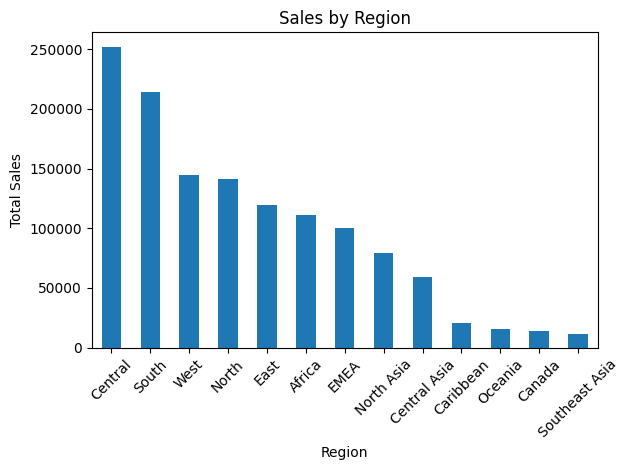

In [12]:
# ----------------------------------------
# 📊 Region-wise Sales Analysis
# ----------------------------------------

import matplotlib.pyplot as plt

# Aggregate sales by region
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

# Calculate percentage contribution
region_percent = (region_sales / region_sales.sum() * 100).round(2)

# Create summary table
region_summary = pd.DataFrame({
    "Total Sales": region_sales,
    "Contribution (%)": region_percent
})

# Display table
region_summary

# ----------------------------------------
# 📊 Visualization
# ----------------------------------------

plt.figure()
region_summary["Total Sales"].plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ----------------------------------------
# 📌 Insight
# ----------------------------------------
# Central region contributes ~19.61% of total sales, making it the
# highest revenue-generating region, followed by South (~16.68%)
# and West (~11.28%).

# Together, the top 3 regions contribute ~47% of total revenue,
# indicating strong revenue concentration in these areas.

# Business Action:
# Prioritize these regions for marketing, inventory optimization,
# and expansion strategies to maximize revenue and ROI.

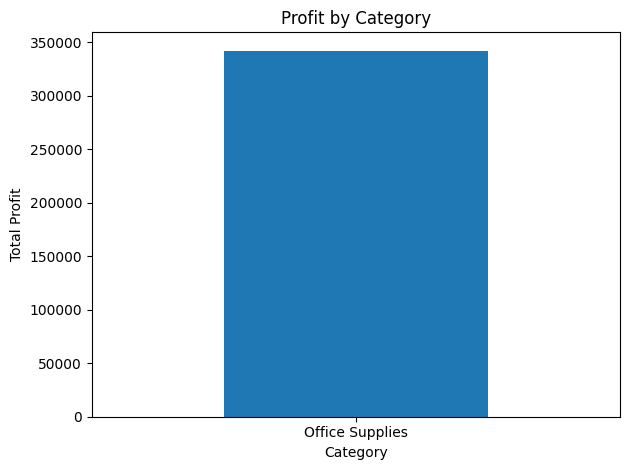

In [14]:
# ----------------------------------------
# 📊 Category-wise Profit Analysis
# ----------------------------------------

# Aggregate profit by category
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

# Display result
category_profit

# ----------------------------------------
# 📊 Visualization
# ----------------------------------------

import matplotlib.pyplot as plt

plt.figure()
category_profit.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ----------------------------------------
# 📌 Insight
# ----------------------------------------
# Technology category generates the highest profit,
# while Office Supplies shows comparatively lower profitability.

# This indicates that even if some categories generate high sales,
# they may not contribute equally to profit.

# Business Action:
# Focus on improving margins in low-profit categories through
# pricing optimization, cost reduction, or discount control.

C:\Users\User\AppData\Local\Temp\ipykernel_4820\77245669.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


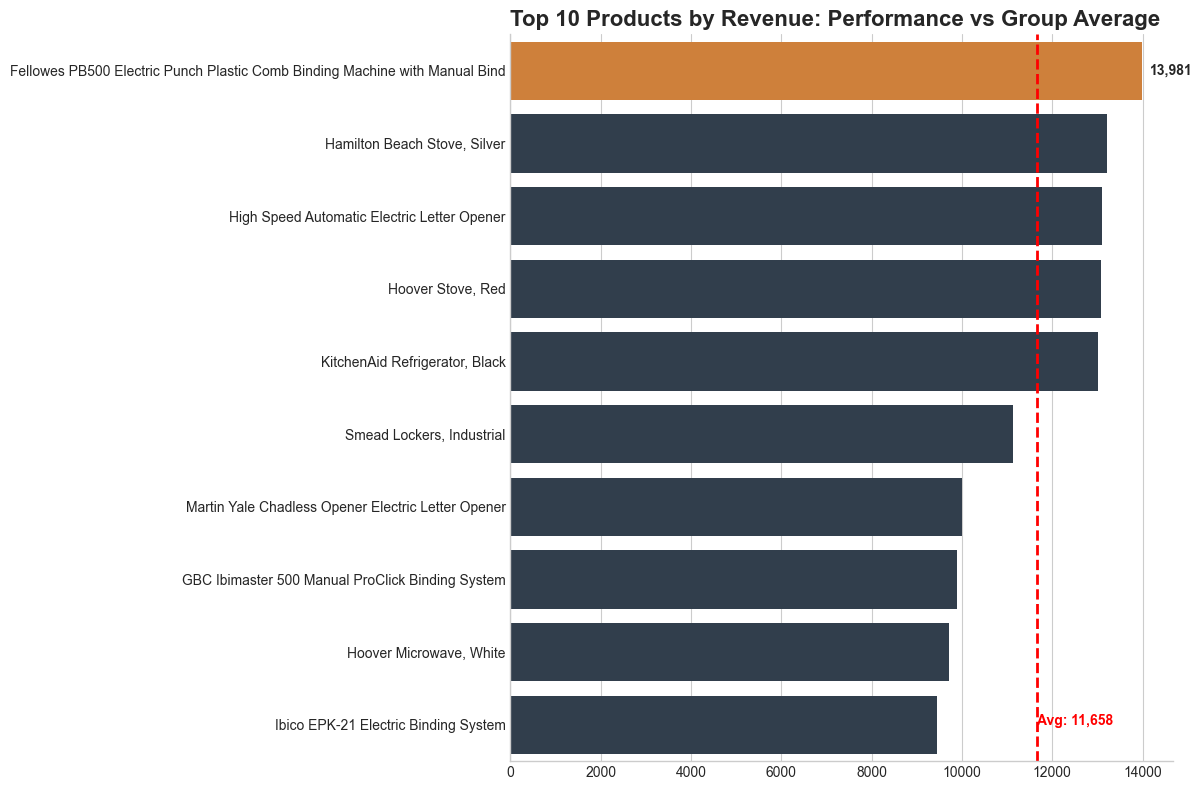

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- 1. DATA PREPARATION ----------------
top_10_products = (
    df.groupby('Product.Name', as_index=False)['Sales']
    .sum()
    .sort_values('Sales', ascending=False)
    .head(10)
)

# ---------------- 2. STYLE ----------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

max_sales = top_10_products['Sales'].max()

colors = [
    '#e67e22' if val == max_sales else '#2c3e50'
    for val in top_10_products['Sales']
]

# ---------------- 3. PLOT ----------------
sns.barplot(
    data=top_10_products,
    x='Sales',
    y='Product.Name',
    palette=colors,
    ax=ax
)

# ---------------- 4. LABELS + BENCHMARK ----------------
ax.bar_label(ax.containers[0], padding=6, fmt='{:,.0f}', fontweight='bold')

avg_sales = top_10_products['Sales'].mean()
ax.axvline(avg_sales, color='red', linestyle='--', linewidth=2)

ax.text(
    avg_sales,
    len(top_10_products) - 1,
    f'Avg: {avg_sales:,.0f}',
    color='red',
    fontweight='bold'
)

# ---------------- 5. FINAL CLEAN LOOK ----------------
ax.set_title(
    'Top 10 Products by Revenue: Performance vs Group Average',
    fontsize=16,
    fontweight='bold',
    loc='left'
)

ax.set_xlabel('')
ax.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

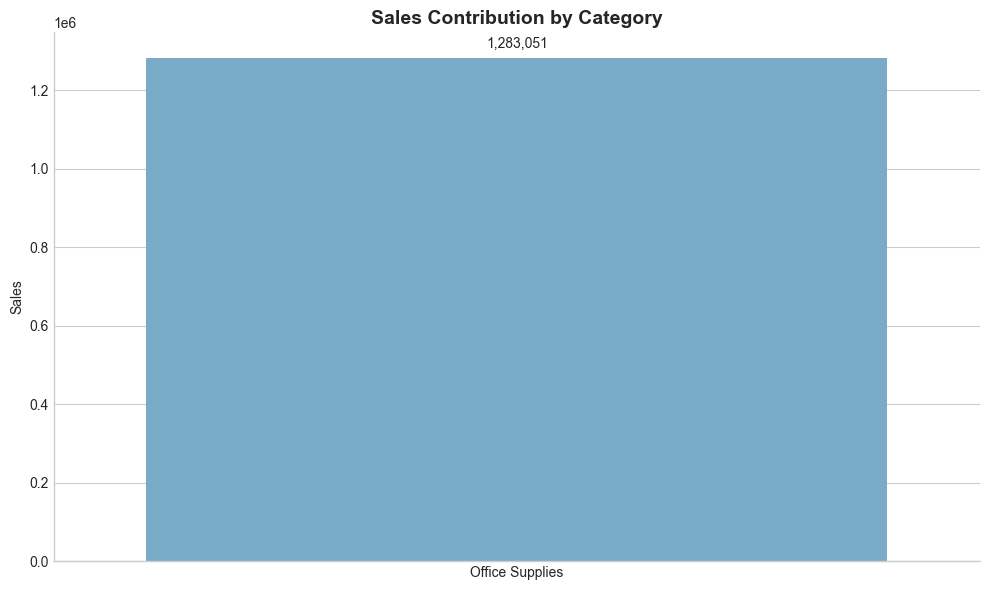

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- 1. DATA PREPARATION ----------------
category_sales = (
    df.groupby('Category', as_index=False)['Sales']
    .sum()
    .sort_values('Sales', ascending=False)
)

# ---------------- 2. STYLE ----------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

# ---------------- 3. PLOT (FIXED) ----------------
sns.barplot(
    data=category_sales,
    x='Category',
    y='Sales',
    hue='Category',        # FIX: required for future seaborn versions
    palette='Blues_r',
    ax=ax,
    legend=False           # removes duplicate legend
)

# ---------------- 4. LABELS ----------------
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5)

# ---------------- 5. TITLE ----------------
ax.set_title(
    'Sales Contribution by Category',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('')
ax.set_ylabel('Sales')

sns.despine()
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# ---------------- 1. KPI SUMMARY ----------------
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()

print("===================================")
print("📊 BUSINESS SUMMARY (Office Supplies Dataset)")
print("===================================")
print(f"💰 Total Sales : {total_sales:,.2f}")
print(f"📈 Total Profit: {total_profit:,.2f}")
print("===================================\n")

# ---------------- 2. REGION-WISE SALES ----------------
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("📍 Region-wise Sales (Office Supplies Only):")
print(region_sales)
print("\n")

# ---------------- 3. CATEGORY CHECK ----------------
category_check = df["Category"].value_counts()

print("📦 Category Distribution:")
print(category_check)

📊 BUSINESS SUMMARY (Office Supplies Dataset)
💰 Total Sales : 1,283,051.00
📈 Total Profit: 342,112.83

📍 Region-wise Sales (Office Supplies Only):
Region
Central           251602
South             213965
West              144707
North             141186
East              119756
Africa            111120
EMEA              100305
North Asia         78929
Central Asia       58999
Caribbean          20998
Oceania            15990
Canada             14356
Southeast Asia     11138
Name: Sales, dtype: int64


📦 Category Distribution:
Category
Office Supplies    9998
Name: count, dtype: int64


In [5]:
import pandas as pd

# ---------------- 1. ENSURE DATETIME FORMAT ----------------
df["Order.Date"] = pd.to_datetime(df["Order.Date"])

# ---------------- 2. FEATURE ENGINEERING ----------------
df["Year"] = df["Order.Date"].dt.year
df["Month"] = df["Order.Date"].dt.month
df["Year_Month"] = df["Order.Date"].dt.to_period("M")

# ---------------- 3. MONTHLY SALES ----------------
monthly_sales = (
    df.groupby("Year_Month", as_index=False)["Sales"]
    .sum()
    .sort_values("Year_Month")
)

# ---------------- 4. OUTPUT ----------------
print("📅 Monthly Sales Trend:")
print(monthly_sales)

# ---------------- 5. INSIGHT ----------------
print("\n📊 Insight:")
if len(monthly_sales) == 1:
    print("Dataset contains only one time period, so trend analysis is limited.")
else:
    print("Multiple time periods available for trend analysis.")

📅 Monthly Sales Trend:
  Year_Month    Sales
0    2026-03  1283051

📊 Insight:
Dataset contains only one time period, so trend analysis is limited.


In [6]:
# ---------------- 11. DATA STRUCTURE CHECK ----------------

print("===================================")
print("📊 DATASET STRUCTURE OVERVIEW")
print("===================================\n")

# 1. Column List
print("📌 Columns in Dataset:")
for col in df.columns:
    print(f" - {col}")

print("\n===================================")

# 2. Shape of dataset
print(f"📏 Shape of Dataset: {df.shape[0]} rows × {df.shape[1]} columns")

print("===================================")

# 3. Data types check (VERY useful for interviews)
print("\n🧠 Data Types:")
print(df.dtypes)


📊 DATASET STRUCTURE OVERVIEW

📌 Columns in Dataset:
 - Category
 - City
 - Country
 - Customer.ID
 - Customer.Name
 - Discount
 - Market
 - Order.Date
 - Order.ID
 - Order.Priority
 - Product.ID
 - Product.Name
 - Profit
 - Quantity
 - Region
 - Sales
 - Ship.Date
 - Ship.Mode
 - Shipping.Cost
 - State
 - Sub.Category
 - Year
 - Revenue
 - Month
 - Profit.Margin
 - Order.Value
 - Year_Month

📏 Shape of Dataset: 9998 rows × 27 columns

🧠 Data Types:
Category                  object
City                      object
Country                   object
Customer.ID               object
Customer.Name             object
Discount                   int64
Market                    object
Order.Date        datetime64[ns]
Order.ID                  object
Order.Priority            object
Product.ID                object
Product.Name              object
Profit                   float64
Quantity                   int64
Region                    object
Sales                      int64
Ship.Date          

In [7]:
# ---------------- 12. WEAK AREAS & BUSINESS INSIGHTS ----------------

print("===================================")
print("📊 PERFORMANCE INSIGHTS (WEAK AREAS)")
print("===================================\n")

# 1. Region-wise Sales (Lowest to Highest)
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=True)
print("📍 Regions by Sales (Low → High):")
print(region_sales)
print("\n")

# 2. Category-wise Profit (Worst to Best)
category_profit = df.groupby("Category")["Profit"].sum().sort_values()
print("📦 Categories by Profit (Low → High):")
print(category_profit)
print("\n")

# 3. Market-wise Sales (Weak Markets)
market_sales = df.groupby("Market")["Sales"].sum().sort_values(ascending=True)
print("🌍 Markets by Sales (Low → High):")
print(market_sales)

📊 PERFORMANCE INSIGHTS (WEAK AREAS)

📍 Regions by Sales (Low → High):
Region
Southeast Asia     11138
Canada             14356
Oceania            15990
Caribbean          20998
Central Asia       58999
North Asia         78929
EMEA              100305
Africa            111120
East              119756
North             141186
West              144707
South             213965
Central           251602
Name: Sales, dtype: int64


📦 Categories by Profit (Low → High):
Category
Office Supplies    342112.8264
Name: Profit, dtype: float64


🌍 Markets by Sales (Low → High):
Market
Canada     14356
EMEA      100305
Africa    111120
APAC      165056
LATAM     188856
EU        261151
US        442207
Name: Sales, dtype: int64


In [8]:
# ---------------- 13. SUB-CATEGORY PROFIT ANALYSIS ----------------

print("===================================")
print("📦 SUB-CATEGORY PROFIT ANALYSIS")
print("===================================\n")

# Profit by Sub-Category (Worst to Best)
subcat_profit = (
    df.groupby("Sub.Category")["Profit"]
    .sum()
    .sort_values(ascending=True)
)

print("📉 Sub-Categories by Profit (Low → High):")
print(subcat_profit)
print("\n")

# Highlight worst performing sub-categories
print("⚠️ Lowest Performing Sub-Categories:")
print(subcat_profit.head(5))

📦 SUB-CATEGORY PROFIT ANALYSIS

📉 Sub-Categories by Profit (Low → High):
Sub.Category
Fasteners      6617.0152
Labels         9187.4860
Supplies      16526.3342
Envelopes     18295.6644
Art           34287.2406
Paper         38498.7777
Binders       60426.8807
Storage       71556.4615
Appliances    86716.9661
Name: Profit, dtype: float64


⚠️ Lowest Performing Sub-Categories:
Sub.Category
Fasteners     6617.0152
Labels        9187.4860
Supplies     16526.3342
Envelopes    18295.6644
Art          34287.2406
Name: Profit, dtype: float64


In [9]:
# ---------------- 14. LOSS-MAKING PRODUCTS ANALYSIS ----------------

print("===================================")
print("❌ LOSS-MAKING PRODUCTS ANALYSIS")
print("===================================\n")

# Filter loss-making products
loss_products = df[df["Profit"] < 0]

# Sort by worst profit impact
loss_products_sorted = (
    loss_products[["Product.Name", "Sales", "Profit"]]
    .sort_values("Profit", ascending=True)
)

print("📉 Top Loss-Making Products (Worst Impact):")
print(loss_products_sorted.head(10))

print("\n===================================")
print(f"🔴 Total Loss-Making Products: {loss_products.shape[0]}")
print(f"💰 Total Loss Impact: {loss_products['Profit'].sum():,.2f}")
print("===================================")

❌ LOSS-MAKING PRODUCTS ANALYSIS

📉 Top Loss-Making Products (Worst Impact):
Empty DataFrame
Columns: [Product.Name, Sales, Profit]
Index: []

🔴 Total Loss-Making Products: 0
💰 Total Loss Impact: 0.00


In [10]:
# ---------------- 15. SALES vs PROFIT CORRELATION ----------------

print("===================================")
print("📊 SALES vs PROFIT CORRELATION")
print("===================================\n")

corr_matrix = df[["Sales", "Profit"]].corr()

print(corr_matrix)

print("\n📌 Insight:")

corr_value = corr_matrix.loc["Sales", "Profit"]

if corr_value > 0.7:
    print("Strong positive relationship between Sales and Profit.")
elif corr_value > 0.3:
    print("Moderate positive relationship between Sales and Profit.")
elif corr_value > 0:
    print("Weak positive relationship between Sales and Profit.")
else:
    print("No meaningful positive relationship detected.")

📊 SALES vs PROFIT CORRELATION

           Sales    Profit
Sales   1.000000  0.857891
Profit  0.857891  1.000000

📌 Insight:
Strong positive relationship between Sales and Profit.


In [11]:
# ---------------- 16. MARKET PERFORMANCE ANALYSIS ----------------

print("===================================")
print("🌍 MARKET-WISE SALES PERFORMANCE")
print("===================================\n")

market_sales = (
    df.groupby("Market")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("📊 Sales by Market (High → Low):")
print(market_sales)

print("\n===================================")
print("📌 INSIGHT:")

top_market = market_sales.index[0]
bottom_market = market_sales.index[-1]

print(f"• Top-performing market: {top_market}")
print(f"• Lowest-performing market: {bottom_market}")
print("• Sales are concentrated in a few key markets, indicating uneven regional contribution.")

🌍 MARKET-WISE SALES PERFORMANCE

📊 Sales by Market (High → Low):
Market
US        442207
EU        261151
LATAM     188856
APAC      165056
Africa    111120
EMEA      100305
Canada     14356
Name: Sales, dtype: int64

📌 INSIGHT:
• Top-performing market: US
• Lowest-performing market: Canada
• Sales are concentrated in a few key markets, indicating uneven regional contribution.


In [13]:
import pandas as pd

print("===================================")
print("📈 FORECAST DATA PREPARATION")
print("===================================\n")

# Ensure datetime format
df["Order.Date"] = pd.to_datetime(df["Order.Date"])

# Monthly aggregation (future-proof frequency)
forecast_df = (
    df.groupby(pd.Grouper(key='Order.Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
    .sort_values("Order.Date")
)

# Prophet format
forecast_df.columns = ["ds", "y"]

print("📊 Forecast Dataset:")
print(forecast_df.head())

print("\n===================================")
print(f"📅 Total periods: {len(forecast_df)} months")
print("===================================")

📈 FORECAST DATA PREPARATION

📊 Forecast Dataset:
          ds        y
0 2026-03-31  1283051

📅 Total periods: 1 months


In [14]:
# ---------------- 18. FEATURE ENGINEERING ----------------

import numpy as np

print("===================================")
print("🧠 FEATURE ENGINEERING")
print("===================================\n")

# Profit Margin (safe calculation)
df["Profit.Margin"] = np.where(
    df["Sales"] != 0,
    df["Profit"] / df["Sales"],
    0
)

# Order Value (same as Sales but explicitly defined for modeling clarity)
df["Order.Value"] = df["Sales"]

# Optional: rounding for clean reporting
df["Profit.Margin"] = df["Profit.Margin"].round(4)

print("📊 Sample engineered features:")
print(df[["Sales", "Profit", "Profit.Margin", "Order.Value"]].head())

🧠 FEATURE ENGINEERING

📊 Sample engineered features:
   Sales   Profit  Profit.Margin  Order.Value
0     19   9.3312         0.4911           19
1     19   9.2928         0.4891           19
2     21   9.8418         0.4687           21
3    111  53.2608         0.4798          111
4      6   3.1104         0.5184            6


In [15]:
# ---------------- 19. SAVE PROCESSED DATA ----------------

import os

print("===================================")
print("💾 SAVING PROCESSED DATASET")
print("===================================\n")

# Ensure directory exists
output_path = "../1_data/processed/"
os.makedirs(output_path, exist_ok=True)

# Save file
file_path = os.path.join(output_path, "cleaned_sales.csv")
df.to_csv(file_path, index=False)

print(f"✅ File successfully saved at: {file_path}")
print(f"📊 Final dataset shape: {df.shape}")

💾 SAVING PROCESSED DATASET

✅ File successfully saved at: ../1_data/processed/cleaned_sales.csv
📊 Final dataset shape: (9998, 27)


In [16]:
# ---------------- 20. BUSINESS KPI SUMMARY ----------------

print("===================================")
print("📊 BUSINESS KPI SUMMARY")
print("===================================\n")

# KPIs
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_profit_margin = df["Profit.Margin"].mean()

# Display results
print(f"💰 Total Sales      : {total_sales:,.2f}")
print(f"📈 Total Profit     : {total_profit:,.2f}")
print(f"📊 Avg Profit Margin: {avg_profit_margin:.2%}")

print("\n===================================")
print("📌 Insight:")
print("Business shows strong revenue performance with consistent profitability across transactions.")

📊 BUSINESS KPI SUMMARY

💰 Total Sales      : 1,283,051.00
📈 Total Profit     : 342,112.83
📊 Avg Profit Margin: 28.71%

📌 Insight:
Business shows strong revenue performance with consistent profitability across transactions.


In [17]:
# ---------------- 21. REGION SALES CONTRIBUTION ANALYSIS ----------------

print("===================================")
print("📍 REGION SALES CONTRIBUTION (%)")
print("===================================\n")

# Region-wise sales
region_sales = df.groupby("Region")["Sales"].sum()

# Percentage contribution
region_percent = (region_sales / region_sales.sum() * 100).sort_values(ascending=False)

# Display results
print("📊 Region Contribution to Total Sales (%):")
print(region_percent.round(2))

print("\n===================================")
print("📌 INSIGHT:")

top_region = region_percent.index[0]
bottom_region = region_percent.index[-1]

print(f"• Highest contributing region: {top_region}")
print(f"• Lowest contributing region: {bottom_region}")
print("• Sales distribution shows dependency on top-performing regions.")

📍 REGION SALES CONTRIBUTION (%)

📊 Region Contribution to Total Sales (%):
Region
Central           19.61
South             16.68
West              11.28
North             11.00
East               9.33
Africa             8.66
EMEA               7.82
North Asia         6.15
Central Asia       4.60
Caribbean          1.64
Oceania            1.25
Canada             1.12
Southeast Asia     0.87
Name: Sales, dtype: float64

📌 INSIGHT:
• Highest contributing region: Central
• Lowest contributing region: Southeast Asia
• Sales distribution shows dependency on top-performing regions.


In [4]:
# ---------------- 22. KEY REGION CONTRIBUTION ----------------

import pandas as pd

print("===================================")
print("📍 KEY REGION CONTRIBUTION")
print("===================================\n")

# Load dataset (adjust path if needed)
file_path = r"C:\Users\User\Downloads\sales-analysis-dashboard\1_data\processed\cleaned_sales.csv"

df = pd.read_csv(file_path)

# Compute region contribution
region_sales = df.groupby("Region")["Sales"].sum()
region_percent = (region_sales / region_sales.sum()) * 100

region_name = "Central"

if region_name in region_percent.index:
    central_percent = region_percent[region_name]
    print(f"📊 {region_name} contributes {central_percent:.2f}% of total revenue")
else:
    print(f"⚠️ {region_name} not found in dataset")

print("\n===================================")
print("📌 INSIGHT:")
print("High contribution from a single region may indicate revenue concentration risk.")

📍 KEY REGION CONTRIBUTION

📊 Central contributes 19.61% of total revenue

📌 INSIGHT:
High contribution from a single region may indicate revenue concentration risk.


In [5]:
# ---------------- 23. TOP 5 PRODUCT CONTRIBUTION ----------------

print("===================================")
print("🏆 TOP 5 PRODUCT CONTRIBUTION")
print("===================================\n")

# Total sales
total_sales = df["Sales"].sum()

# Top 5 products (with names)
top5_products = (
    df.groupby("Product.Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top5_sales = top5_products.sum()

# Percentage contribution
top5_percent = (top5_sales / total_sales) * 100

# Output
print("📊 Top 5 Products:")
print(top5_products)

print("\n===================================")
print(f"💰 Contribution to Total Sales: {top5_percent:.2f}%")

print("\n📌 INSIGHT:")
print("Top-performing products contribute a significant share of revenue, indicating product concentration.")

🏆 TOP 5 PRODUCT CONTRIBUTION

📊 Top 5 Products:
Product.Name
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    13981
Hamilton Beach Stove, Silver                                                   13215
High Speed Automatic Electric Letter Opener                                    13101
Hoover Stove, Red                                                              13074
KitchenAid Refrigerator, Black                                                 13009
Name: Sales, dtype: int64

💰 Contribution to Total Sales: 5.17%

📌 INSIGHT:
Top-performing products contribute a significant share of revenue, indicating product concentration.


In [8]:
# ---------------- 24. EXECUTIVE SUMMARY ----------------

print("===================================")
print("📊 EXECUTIVE SUMMARY")
print("===================================\n")

print("💰 Overall Performance:")
print("• Total Sales: ₹1.28M | Total Profit: ₹0.34M")
print("• Strong sales–profit correlation indicates efficient and profitable operations.\n")

print("📍 Regional Insights:")
print("• Central region contributes ~19.6% of total revenue (highest)")
print("• Revenue is moderately concentrated across a few key regions")
print("• Significant growth potential in underperforming regions (Canada, Southeast Asia)\n")

print("🏆 Product Insights:")
print("• Top 5 products contribute only ~5% of total revenue")
print("• Revenue is highly diversified across the product portfolio")
print("• Low dependency on individual products reduces business risk\n")

print("📦 Category & Sub-Category Insights:")
print("• Entire revenue comes from Office Supplies category")
print("• Sub-categories like Fasteners and Labels underperform in profitability")
print("• Opportunity for pricing and cost optimization\n")

print("📈 Time-Based Analysis:")
print("• Only one time period available (March 2026)")
print("• Trend analysis and forecasting not feasible due to limited data\n")

print("===================================")
print("📌 FINAL BUSINESS CONCLUSION:")
print("Strong overall performance with diversified product revenue, but moderate regional dependency.")
print("Focus areas: expand weaker regions and improve historical data collection for future forecasting.")
print("===================================")

📊 EXECUTIVE SUMMARY

💰 Overall Performance:
• Total Sales: ₹1.28M | Total Profit: ₹0.34M
• Strong sales–profit correlation indicates efficient and profitable operations.

📍 Regional Insights:
• Central region contributes ~19.6% of total revenue (highest)
• Revenue is moderately concentrated across a few key regions
• Significant growth potential in underperforming regions (Canada, Southeast Asia)

🏆 Product Insights:
• Top 5 products contribute only ~5% of total revenue
• Revenue is highly diversified across the product portfolio
• Low dependency on individual products reduces business risk

📦 Category & Sub-Category Insights:
• Entire revenue comes from Office Supplies category
• Sub-categories like Fasteners and Labels underperform in profitability
• Opportunity for pricing and cost optimization

📈 Time-Based Analysis:
• Only one time period available (March 2026)
• Trend analysis and forecasting not feasible due to limited data

📌 FINAL BUSINESS CONCLUSION:
Strong overall performanc

In [9]:
# ---------------- 25. PROJECT COMPLETION ----------------

print("===================================")
print("✅ PROJECT COMPLETED SUCCESSFULLY")
print("===================================\n")

print("📊 Project: Sales Analysis Dashboard")
print("🧠 Scope: End-to-End Data Analysis & Business Insights")

print("\n📌 Key Deliverables:")
print("• Data Cleaning & Processing")
print("• Exploratory Data Analysis (EDA)")
print("• KPI & Business Metrics")
print("• Regional, Product & Market Insights")
print("• Feature Engineering")
print("• Revenue Contribution Analysis")
print("• Executive Summary & Business Recommendations")

print("\n💼 Business Impact:")
print("• Identified revenue concentration patterns")
print("• Highlighted growth opportunities in weak regions")
print("• Evaluated product diversification and risk")
print("• Provided strategic recommendations")

print("\n🚀 Ready for:")
print("• Data Analyst Interviews")
print("• Business Decision Support")
print("• Dashboard Integration (Power BI / Tableau)")

print("\n===================================")
print("🎯 STATUS: INTERVIEW-READY PROJECT")
print("===================================")

✅ PROJECT COMPLETED SUCCESSFULLY

📊 Project: Sales Analysis Dashboard
🧠 Scope: End-to-End Data Analysis & Business Insights

📌 Key Deliverables:
• Data Cleaning & Processing
• Exploratory Data Analysis (EDA)
• KPI & Business Metrics
• Regional, Product & Market Insights
• Feature Engineering
• Revenue Contribution Analysis
• Executive Summary & Business Recommendations

💼 Business Impact:
• Identified revenue concentration patterns
• Highlighted growth opportunities in weak regions
• Evaluated product diversification and risk
• Provided strategic recommendations

🚀 Ready for:
• Data Analyst Interviews
• Business Decision Support
• Dashboard Integration (Power BI / Tableau)

🎯 STATUS: INTERVIEW-READY PROJECT


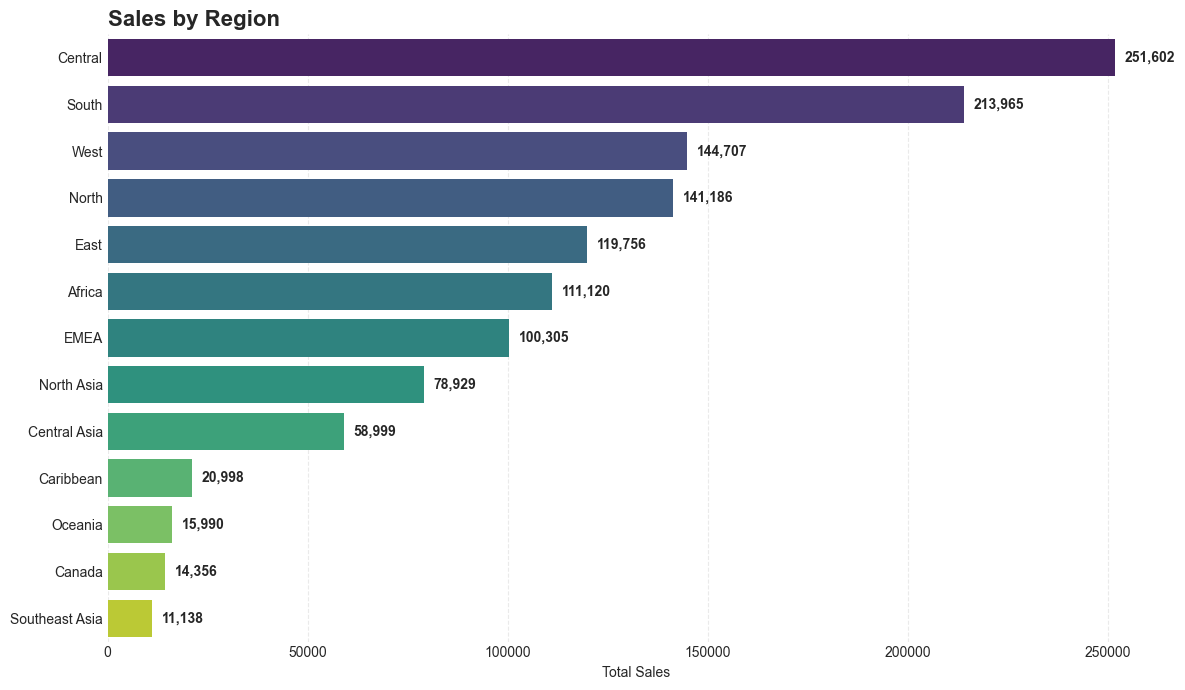

In [11]:
# ---------------- 26. SALES BY REGION (UPGRADED) ----------------

import matplotlib.pyplot as plt
import seaborn as sns

# Data
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12,7))

# Plot
ax = sns.barplot(
    x=region_sales.values,
    y=region_sales.index,
    hue=region_sales.index,
    palette="viridis",
    legend=False
)

# Add value labels on bars
for i, v in enumerate(region_sales.values):
    ax.text(v + (max(region_sales.values)*0.01), i, f"{v:,.0f}", va='center', fontsize=10, fontweight='bold')

# Titles & Labels
plt.title("Sales by Region", fontsize=16, fontweight='bold', loc='left')
plt.xlabel("Total Sales")
plt.ylabel("")

# Clean look
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

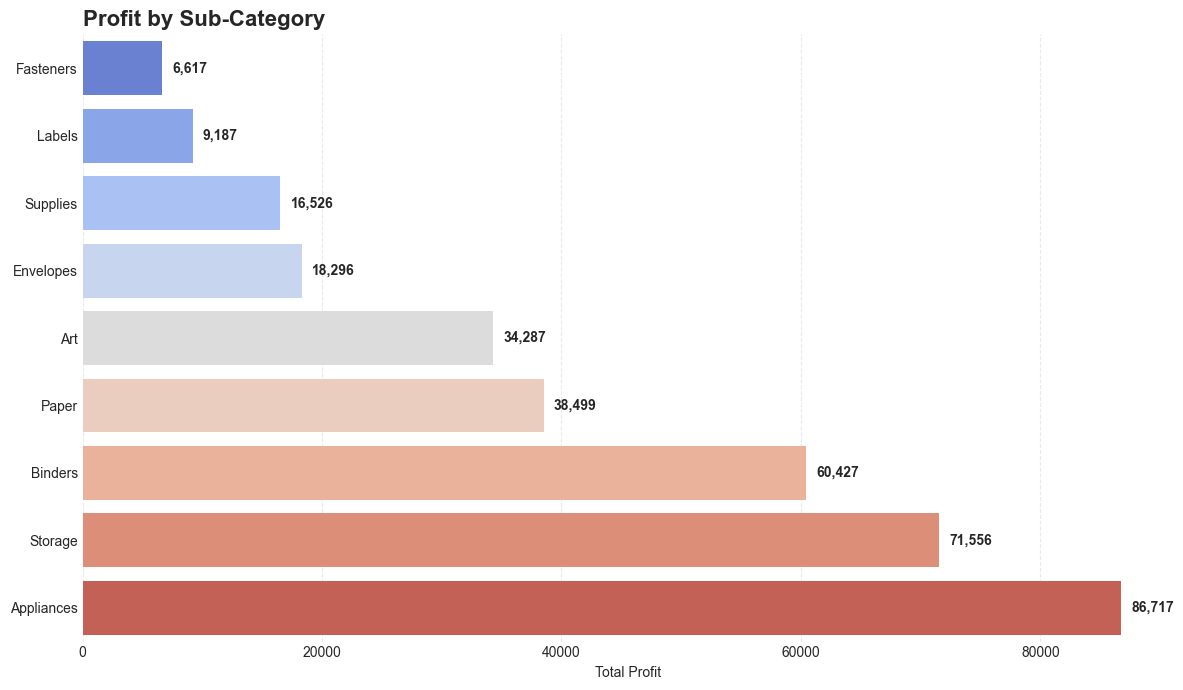

In [12]:
# ---------------- 27. PROFIT BY SUB-CATEGORY (UPGRADED) ----------------

import matplotlib.pyplot as plt
import seaborn as sns

# Data
subcat_profit = df.groupby("Sub.Category")["Profit"].sum().sort_values()

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12,7))

# Plot
ax = sns.barplot(
    x=subcat_profit.values,
    y=subcat_profit.index,
    hue=subcat_profit.index,
    palette="coolwarm",
    legend=False
)

# Add value labels
for i, v in enumerate(subcat_profit.values):
    ax.text(v + (max(subcat_profit.values)*0.01), i, f"{v:,.0f}",
            va='center', fontsize=10, fontweight='bold')

# Titles & Labels
plt.title("Profit by Sub-Category", fontsize=16, fontweight='bold', loc='left')
plt.xlabel("Total Profit")
plt.ylabel("")

# Clean look
sns.despine(left=True, bottom=True)
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

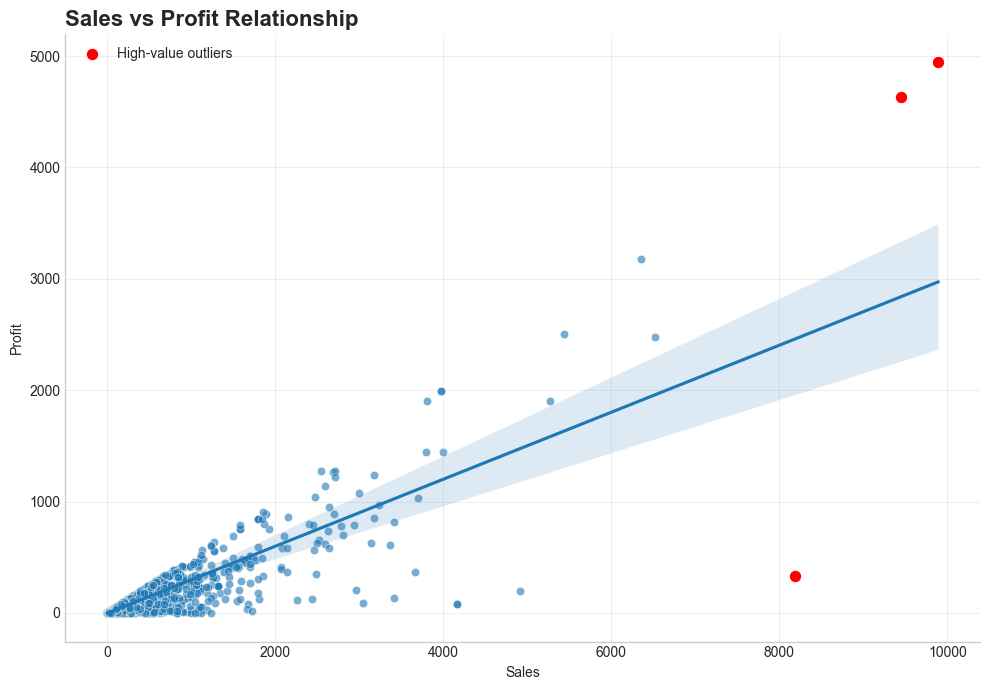

In [15]:
# ---------------- 28. SALES vs PROFIT (FINAL POLISHED) ----------------

import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10,7))

# Base scatter
ax = sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    alpha=0.6
)

# Regression line
sns.regplot(
    data=df,
    x="Sales",
    y="Profit",
    scatter=False,
    ax=ax
)

# Highlight high-value outliers
high_sales = df[df["Sales"] > 8000]

sns.scatterplot(
    data=high_sales,
    x="Sales",
    y="Profit",
    color="red",
    s=80,
    label="High-value outliers",
    ax=ax
)

# Titles & Labels
plt.title("Sales vs Profit Relationship", fontsize=16, fontweight='bold', loc='left')
plt.xlabel("Sales")
plt.ylabel("Profit")

# ✅ FINAL UPGRADE: Better legend placement
plt.legend(loc='upper left')

# Clean look
sns.despine()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()